In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **CNN Class**

In [16]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self .classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.70MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


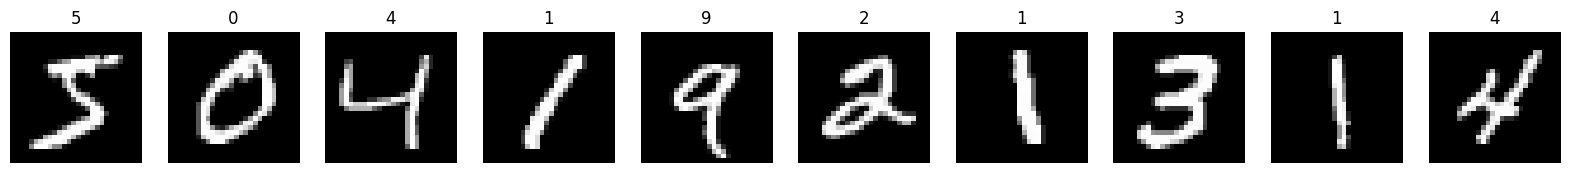

In [12]:

fig, axes = plt.subplots(1, 10, figsize=(20, 3))

for i in range(10):
    image, label = train_dataset[i]

    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

# Task 1: Training Loop


The training loops consists of mainly 5 steps-

1.   Zero old gradients
2.   Forward pass
3.   Loss Computation
4.   Backward Pass
5.   Update weights







Loss function -

>For MNIST dataset Cross Entropy Loss is preferred over NLL Loss because it combines nn.LogSoftmax() and nn.NLLLoss() into a single class  and return the output as raw unormalized called logits



Optimizer-
>Adam optimizer is prefered over SGD because the convergence rate of Adam is more than SGD. Which makes it suitable for experimentation.


Learning Rate Schedulers-

>It is important to a suitable learning rate so that it is neither too high nor too low. If the learning rate is too high then the model will overshoot the global minimum and if the rate is too low then the descent will be really slow and it will take very high number of epochs to reach the minimum. To tackle this scheduler is add which keeps the learning rate high at the start of leaning it reduced it when it reaches near the minimum.

#Train Function Implementation

In [56]:
def train(model,device,train_loader,optimizer,epoch):
    model.train()
    running_loss=0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"Epoch {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(data):.6f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch} Loss: {epoch_loss:.6f}")
    return epoch_loss

# Task 2- Evaluation

##model.eval() is needed because-


1.   Dropout - During training the data certain percentage of neurons are deactivated to prevent codependecy. But during the evaluation all nearons are required hence no dropout is needed.
2.   Batch Nomarlization - During evaluation it the model stops calculating means and variances for the data. Instead it prefers the data obtained after the training of data



**torch.no_grad** is used to reduce memory consumption and speed up computation as it stops pytorch from tracking gradients during operations

##Test Function Implementation

In [18]:
def test(model,device,test_loader,criterion):
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      data,target = data.to(device), target.to(device)
      output = model(data)
      test_loss += criterion(output, target).item()
      pred = output.argmax(dim=1, keepdim=True)
      correct +=pred.eq(target.view_as(pred)).sum().item()
  test_loss /= len(test_loader.dataset)
  accuracy = 100.*correct/len(test_loader.dataset)
  print(f"Test set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)")
  return test_loss,accuracy

In [57]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

train_losses = []
test_losses = []
test_accuracies = []

epochs = 10
for epoch in range(1, epochs + 1):
    train_loss = train(model, device, train_loader, optimizer, epoch)
    test_loss, accuracy = test(model, device, test_loader, criterion)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(accuracy)

Epoch 1 [0/60000 (0%)]	Loss: 0.040489
Epoch 1 [12800/60000 (21%)]	Loss: 0.001542
Epoch 1 [25600/60000 (43%)]	Loss: 0.002598
Epoch 1 [38400/60000 (64%)]	Loss: 0.003072
Epoch 1 [51200/60000 (85%)]	Loss: 0.004244
Epoch 1 Loss: 0.003158
Test set: Average loss: 0.0002, Accuracy: 9847/10000 (98.47%)
Epoch 2 [0/60000 (0%)]	Loss: 0.001321
Epoch 2 [12800/60000 (21%)]	Loss: 0.000320
Epoch 2 [25600/60000 (43%)]	Loss: 0.002460
Epoch 2 [38400/60000 (64%)]	Loss: 0.000869
Epoch 2 [51200/60000 (85%)]	Loss: 0.001005
Epoch 2 Loss: 0.001532
Test set: Average loss: 0.0002, Accuracy: 9871/10000 (98.71%)
Epoch 3 [0/60000 (0%)]	Loss: 0.000654
Epoch 3 [12800/60000 (21%)]	Loss: 0.000547
Epoch 3 [25600/60000 (43%)]	Loss: 0.000093
Epoch 3 [38400/60000 (64%)]	Loss: 0.000522
Epoch 3 [51200/60000 (85%)]	Loss: 0.002178
Epoch 3 Loss: 0.001019
Test set: Average loss: 0.0001, Accuracy: 9907/10000 (99.07%)
Epoch 4 [0/60000 (0%)]	Loss: 0.001109
Epoch 4 [12800/60000 (21%)]	Loss: 0.002581
Epoch 4 [25600/60000 (43%)]	Loss: 

##Overfitting -
>Overfitting occurs when model memorizes the data rather than generalizing it. It can be seen when training loss keeps on decreasing but test loss starts increasing.


# Task 3- Save, Load and Reflect

##Saving-


1.   Full Model - It is convienient to access. But if the file struction or directory is changed then it will not be able to load it.
2.   State dict - Saves only a Python dictionary mapping each layer to its parameter tensors


In [21]:
torch.save(model.state_dict(),
           'mnist_cnn.pt')
print(f"Model state dict successfully saved to mnist_cnn.pt")

Model state dict successfully saved to mnist_cnn.pt


## Loading

In [22]:
loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load('mnist_cnn.pt',
                                        map_location=device))
loaded_model.eval()
print("Model loaded sucessfully")

Model loaded sucessfully


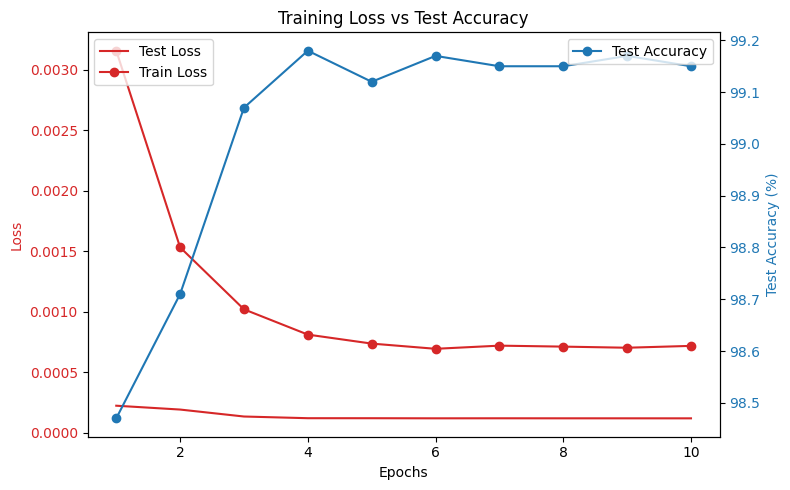

In [58]:
fig, ax1 = plt.subplots(figsize=(8, 5))


color = 'tab:red'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color=color)
ax1.plot(range(1, epochs + 1), test_losses, label='Test Loss', color=color,)
ax1.plot(range(1, epochs + 1), train_losses, label='Train Loss', color=color, marker='o')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')


ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(range(1, epochs + 1), test_accuracies, label='Test Accuracy', color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title('Training Loss vs Test Accuracy')
fig.tight_layout()
plt.show()

Clearly

Prediction: 3
Actual: 3


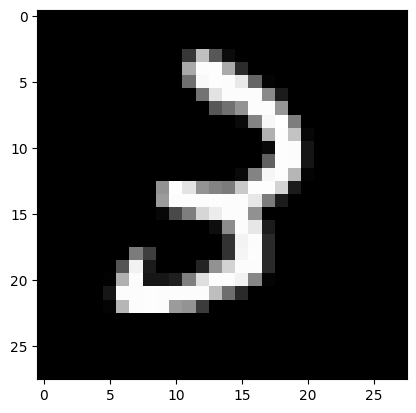

In [41]:
import random
image, label = test_dataset[random.randint(1,100)]
plt.imshow(
    image.squeeze(),
    cmap="gray"
)

image = image.unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(image)
    pred = output.argmax(dim=1)

print("Prediction:", pred.item())
print("Actual:", label)

##Reflection-

The model gave an accuracy of 99.15% after running for 10 epochs. As the epochs increase both training loss and test loss decrease and become near constant after some time thus overfitting is not there. Test accuracy increases with more epochs.

## Improvements -
1. More epochs - On increasing the number of epochs the model will achieve higher accuracy. However if the number of epochs are too many then the data will start overfitting

2. Data Augmentation - It will provide more data for training by using slight rotation, translation, etc on the dataset.

3. Add more convulational layers


